# 06 — Transfer learning

**Day 2 · Notebook 2 of 3**

The single most useful skill in applied CV: take a tiny dataset, pick a
pretrained backbone, swap the head, fine-tune. This is how 90% of real
CV projects start.

Today we'll classify **ants vs. bees** from 244 training images. From
scratch, that's hopeless. With a ResNet18 pretrained on ImageNet, we'll
cross 90% val accuracy in under a minute.

## Objectives

- Load a pretrained model and replace its classifier head.
- Run **feature extraction** (freeze the backbone, train only the head).
- Run **fine-tuning** (unfreeze, lower LR for the backbone).
- Recognize the 3 transfer-learning pitfalls that eat the most time.
- Swap in any of `timm`'s 1000+ pretrained models with one line.


## 1. The dataset — Hymenoptera (244 images, 2 classes)

The canonical "transfer learning works, training from scratch doesn't"
dataset, from the official PyTorch tutorial. ~50 MB, downloads in seconds.


In [1]:
import urllib.request, zipfile
from pathlib import Path

DATA_DIR = Path("../data/hymenoptera_data")
if not DATA_DIR.exists():
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    zip_path = Path("../data/hymenoptera_data.zip")
    zip_path.parent.mkdir(parents=True, exist_ok=True)
    print("downloading...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(zip_path.parent)
    zip_path.unlink()
print("ready:", DATA_DIR)
print("contents:", sorted(p.name for p in DATA_DIR.iterdir()))

downloading...
ready: ../data/hymenoptera_data
contents: ['train', 'val']


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

from cvcourse import get_device, show_grid, plot_history

device = get_device()
print("device:", device)

# A plain pipeline for the from-scratch baseline. We'll swap in the
# pretrained-model preprocessing later.
plain_pipeline = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

train_ds = ImageFolder(DATA_DIR / "train", transform=plain_pipeline)
val_ds   = ImageFolder(DATA_DIR / "val",   transform=plain_pipeline)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

class_names = train_ds.classes
print(f"train {len(train_ds)}  val {len(val_ds)}  classes {class_names}")

device: mps
train 244  val 153  classes ['ants', 'bees']


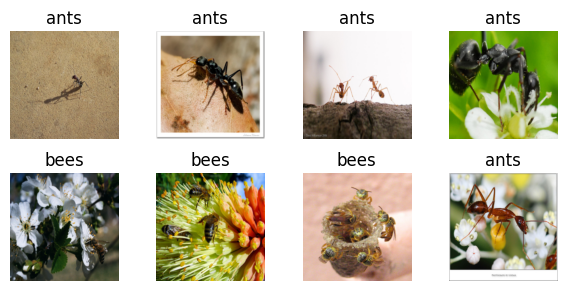

In [3]:
# One batch — make sure the data actually looks like what you think it does.
xb, yb = next(iter(train_loader))
show_grid(xb[:8], titles=[class_names[y] for y in yb[:8]], cols=4)

## 2. Train/eval helpers (same as nb 05)

Notebooks are independent — students might land here directly — so we
redefine the loop helpers once. Nothing new vs. notebook 05.


In [4]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in tqdm(loader, leave=False):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += xb.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss_sum += loss.item() * xb.size(0)
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += xb.size(0)
    return loss_sum / total, correct / total


def fit(model, train_loader, val_loader, optimizer, epochs, device):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, device)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"epoch {epoch:2d}  train {tr_loss:.3f}/{tr_acc:.3f}  "
              f"val {va_loss:.3f}/{va_acc:.3f}")
    return history

## 3. Baseline — train from scratch (and watch it fail)

Before pulling out pretrained weights, see what 244 images can do on their
own. We use the same `SmallCNN_v2` shape from notebook 05, adapted to
3-channel 224×224 inputs.


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  1  train 0.682/0.574  val 0.703/0.458


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  2  train 0.623/0.619  val 0.725/0.458


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  3  train 0.600/0.648  val 0.769/0.458


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  4  train 0.584/0.689  val 0.751/0.490


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  5  train 0.563/0.701  val 0.696/0.562


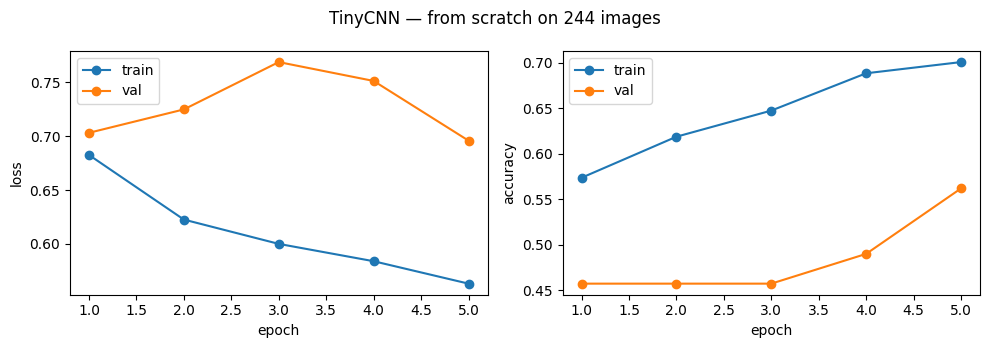

In [5]:
class TinyCNN(nn.Module):
    def __init__(self, n_classes: int = 2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.fc    = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.max_pool2d(F.relu(self.bn3(self.conv3(x))), 2)
        x = self.gap(x).flatten(1)
        return self.fc(x)


model = TinyCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history_scratch = fit(model, train_loader, val_loader, optimizer, epochs=5, device=device)
plot_history(history_scratch, title="TinyCNN — from scratch on 244 images")

Val accuracy hovers near chance. 244 images is nowhere near enough for a
network to learn what an edge, a texture, or a wing is from pixels alone.

A network trained on ImageNet has already learned all of that. We just
need to teach it the _last_ step — "of these features, which mean ant and
which mean bee?".


## 4. Load a pretrained ResNet18

`torchvision.models` ships dozens of architectures. The modern API hands
you the weights enum _and_ the exact preprocessing the model was trained
with — so you can't get normalization wrong.


In [6]:
from torchvision.models import resnet18, ResNet18_Weights
from torchinfo import summary

weights = ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()   # the correct resize + normalize for this model
print(preprocess)

model = resnet18(weights=weights).to(device)
summary(model, input_size=(1, 3, 224, 224), device=device)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

Two things to notice:

- **~11M parameters** — vs. ~10k in our TinyCNN. All of them already trained.
- The final layer is **`fc: Linear(512, 1000)`** — it predicts ImageNet's
  1000 classes. We have 2. The head has to go.


## 5. Swap the head, swap the preprocessing

Replace `fc` with a fresh `Linear(512, 2)`. The new layer is randomly
initialized; everything below it keeps its ImageNet weights.

Then rebuild the loaders with `preprocess` so inputs match what the model
was trained on (ImageNet mean/std, 224×224 center crop).


In [7]:
num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes).to(device)
print(model.fc)

train_ds_pre = ImageFolder(DATA_DIR / "train", transform=preprocess)
val_ds_pre   = ImageFolder(DATA_DIR / "val",   transform=preprocess)
train_loader_pre = DataLoader(train_ds_pre, batch_size=32, shuffle=True,  num_workers=0)
val_loader_pre   = DataLoader(val_ds_pre,   batch_size=32, shuffle=False, num_workers=0)

Linear(in_features=512, out_features=2, bias=True)


## 6. Strategy A — Feature extraction (frozen backbone)

Freeze every parameter, then unfreeze only the new head. Now
`model.parameters()` still walks the whole network, but `requires_grad`
on all but `fc` is `False`, so `optimizer.step()` only updates the head.

**Why this is fast:** the backbone is computed once per batch (the
forward pass) but no gradients flow through it.


trainable: 1,026  /  total: 11,177,538  (0.01%)


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  1  train 0.572/0.697  val 0.435/0.869


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  2  train 0.405/0.861  val 0.336/0.895


...

epoch  3  train 0.307/0.922  val 0.291/0.915


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  4  train 0.260/0.914  val 0.254/0.928


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  5  train 0.230/0.939  val 0.240/0.922


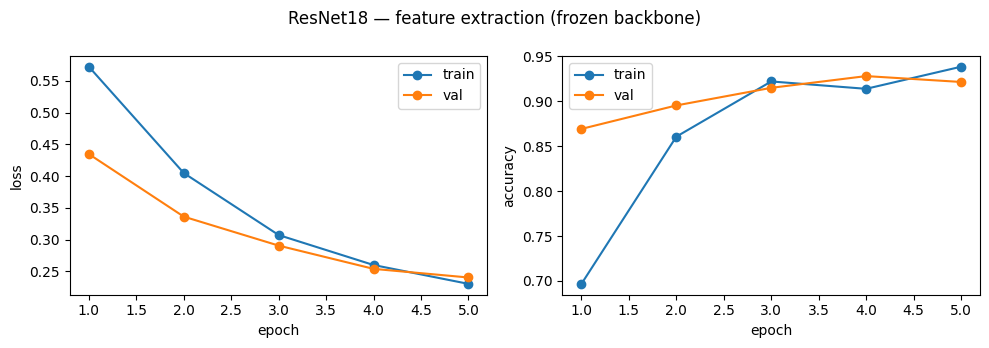

In [8]:
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"trainable: {trainable:,}  /  total: {total:,}  ({trainable/total:.2%})")

# Only pass the params we actually want to update.
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
history_feat = fit(model, train_loader_pre, val_loader_pre, optimizer, epochs=5, device=device)
plot_history(history_feat, title="ResNet18 — feature extraction (frozen backbone)")

> 1000 trainable parameters, ~5 epochs, **>90% val accuracy**. Compare to
> the from-scratch run that couldn't beat chance.

## 7. Strategy B — Fine-tuning (unfreeze, two LRs)

Feature extraction treats the pretrained features as fixed. Fine-tuning
lets them _adapt_ to your dataset — usually another 2–5 points of
accuracy at the cost of a longer training run.

The realistic recipe is **per-group learning rates**: the new head needs a
big LR (it's random), the pretrained backbone needs a small one (its
features are precious — too-large gradients erase them).


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  1  train 0.171/0.943  val 0.157/0.935


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  2  train 0.040/0.980  val 0.204/0.948


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  3  train 0.011/0.996  val 0.231/0.928


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  4  train 0.008/0.996  val 0.197/0.941


  0%|          | 0/8 [00:00<?, ?it/s]

epoch  5  train 0.003/1.000  val 0.219/0.941


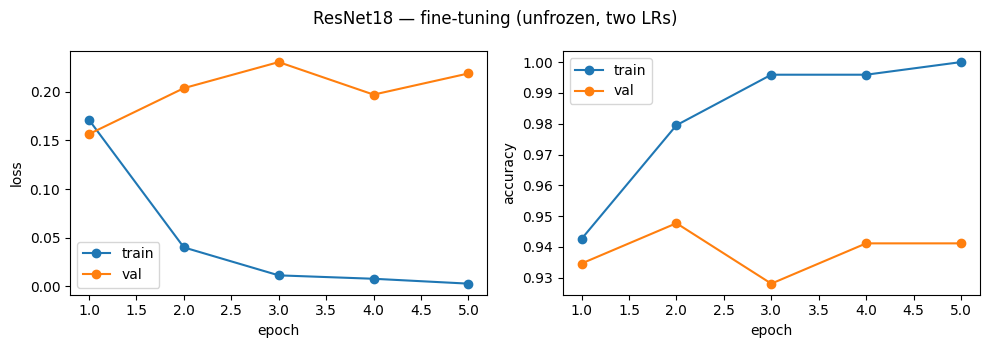

In [9]:
for p in model.parameters():
    p.requires_grad = True

# Two param groups: head gets 1e-3, backbone gets 1e-4.
head_params     = list(model.fc.parameters())
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
optimizer = torch.optim.AdamW([
    {"params": head_params,     "lr": 1e-3},
    {"params": backbone_params, "lr": 1e-4},
])

history_ft = fit(model, train_loader_pre, val_loader_pre, optimizer, epochs=5, device=device)
plot_history(history_ft, title="ResNet18 — fine-tuning (unfrozen, two LRs)")

## 8. Compare all three runs on one chart


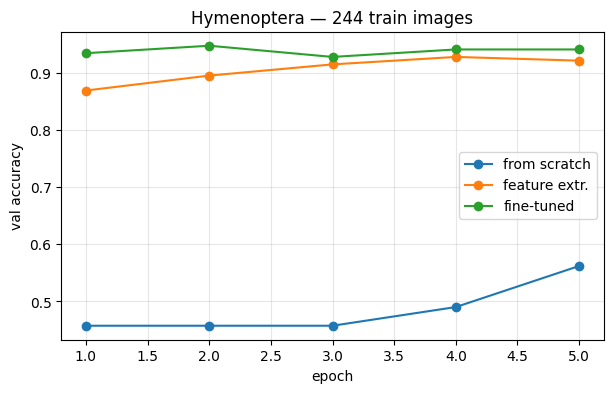

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
for name, h in [
    ("from scratch",   history_scratch),
    ("feature extr.",  history_feat),
    ("fine-tuned",     history_ft),
]:
    plt.plot(range(1, len(h["val_acc"]) + 1), h["val_acc"], "-o", label=name)
plt.xlabel("epoch"); plt.ylabel("val accuracy"); plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Hymenoptera — 244 train images"); plt.show()

## 9. The pitfalls that eat the most time

1. **Wrong normalization.** Torchvision pretrained models expect ImageNet
   mean/std. If you feed them your own dataset's stats (or raw `[0, 1]`),
   accuracy silently degrades. Always use `weights.transforms()` — it
   bakes in the right preprocessing for that specific checkpoint.

2. **Wrong input size.** Most ImageNet models want **224×224**. Some
   (Inception, EfficientNet-B7) want 299, 600, or other sizes. Again,
   `weights.transforms()` handles it.

3. **Backbone LR too high.** A pretrained backbone is the most valuable
   part of your model. Use `≤ 1e-4` on it (often `1e-5`). The head, being
   random, needs `1e-3` or higher. Per-group LRs are the standard tool.

4. **BatchNorm running stats drifting on tiny batches.** When fine-tuning
   on a very small dataset with small batches, BN's running mean/var can
   wander away from the ImageNet statistics. Mitigation: keep the
   backbone in `.eval()` mode during the feature-extraction phase, or
   freeze BN layers explicitly.

5. **Forgot to swap the head.** The new task has `K` classes; the
   pretrained `fc` predicts 1000. The error you'd get on a loss against
   2-class labels is `IndexError` or a bizarre loss value — easy to
   mistake for something deeper. Always re-print the model after the
   swap.


## 10. `timm` — 1000+ pretrained models in one line

[`timm`](https://github.com/huggingface/pytorch-image-models) ships
practically every state-of-the-art image backbone (EfficientNet, ConvNeXt,
Swin, BEiT, DINOv2, ...) behind a single `create_model` call. The same
freeze/unfreeze recipe you just learned applies unchanged.

`num_classes=` even handles the head swap for you.


In [11]:
import timm

model_timm = timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)
model_timm = model_timm.to(device)

# timm models carry their own preprocessing recipe — use it.
cfg = timm.data.resolve_model_data_config(model_timm)
timm_preprocess = timm.data.create_transform(**cfg, is_training=False)
print(timm_preprocess)

# Quick sanity check — one forward pass on a real batch.
xb, _ = next(iter(val_loader_pre))
with torch.no_grad():
    logits = model_timm(xb.to(device))
print("logits shape:", logits.shape)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)
logits shape: torch.Size([32, 2])


To train it: same `fit(...)` call, same freeze/unfreeze pattern. Pick the
catalog with `timm.list_models(pretrained=True)`.

## Wrap-up

You took 244 images and a pretrained ResNet18 and built a >90% classifier
in under a minute. That's the recipe for the vast majority of applied CV
projects — not "design a new architecture", but "pick a backbone, swap
the head, fine-tune".

> **Next notebook (07):** Grad-CAM — _see_ which pixels the model used to
> decide "ant" vs "bee", and learn to spot when it's right for the
> wrong reasons.
